# Lecture 4: Exericse 1 - Solution


## Objective

The goal of this assignment is to perform sentiment analysis with a lexicon-based approach on social media posts. You will explore the impact of **negation** handling by introducing bigrams and **compare** different lexicon **tools**.

## Data

Scrape at least 500 posts about your topic of choice via Mastodon or Bsky. You are free to use the same topic for the first and second task or not.

## Task 1: implementing negation

Extend the analysis of the **Lexicon-based Approach Section** of the notebook of Lecture 4 by adding negation. You should use our own scraped data and incorporate bigrams to handle negation (e.g., “not good” --> negative sentiment).

- **Create** a **new sentiment dictionary** that includes both **unigrams and negated bigrams** (Tip: use the original Likert scale for creating the new valence scores).  
- **Split** your dataset into **unigrams only, bigrams only, and a combination of both**, then apply the sentiment dictionary to each.  
- **Perform** sentiment analysis using **a unigram dictionary** and once using **a bigram dictionary**.  
- **Plot** the sentiment scores, add a **reference line** based on **unigram-only** analysis, and compute the correlation between both sentiment curves.  
- **Discuss** your insights about negation handling.


💡 To **implement bi-grams** use the following piece of code:

In [1]:
from nltk import ngrams
from nltk.tokenize import word_tokenize

text = "This is not good"

# Split in unigrams
unigrams = word_tokenize(text)
print(unigrams)
# ['This', 'is', 'not', 'good']

# Split in bigrams
bigrams_list = list(ngrams(unigrams, 2))
print(bigrams_list)
# [('This', 'is'), ('is', 'not'), ('not', 'good')]

# Join bigrams as strings
bigrams = [' '.join(bigram) for bigram in bigrams_list]
print(bigrams)
# ['This is', 'is not', 'not good']

['This', 'is', 'not', 'good']
[('This', 'is'), ('is', 'not'), ('not', 'good')]
['This is', 'is not', 'not good']


### Solution

We'll implement negation handling in sentiment analysis by creating a dictionary that includes both unigrams and negated bigrams. The approach involves:

1. **Data Collection**: Scrape toots from Mastodon about #ClimateChange (a polarizing topic with diverse sentiments)
2. **Dictionary Setup**: Create negation dictionary using the original Likert scale (1-9)
3. **Unigram Analysis**: Baseline sentiment using single words only
4. **Negation Analysis**: Enhanced sentiment using both unigrams and bigrams (handles "not good")
5. **Comparison**: Visualize and correlate both approaches to understand the impact of negation handling

#### Step 1: Data Collection from Mastodon

First, we'll collect English toots about #ClimateChange for our analysis. Climate change is a polarizing topic that generates strong opinions across the political spectrum, making it ideal for sentiment analysis with negation.

In [2]:
# Import required libraries
from mastodon import Mastodon
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk import ngrams
import nltk
import os

# Import Mastodon utility functions
import sys
# Get the directory where this notebook is located
notebook_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
# Construct absolute path to mastodon_utils
utils_path = os.path.join(notebook_dir, '..', '..', '..', 'Lecture1', 'Code', 'Examples')
utils_path = os.path.abspath(utils_path)
sys.path.append(utils_path)
from mastodon_utils import fetch_hashtag_toots, add_clean_content, filter_by_language, select_columns

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Initialize Mastodon client
from mastodon_config import MASTODON_ACCESS_TOKEN, MASTODON_API_BASE_URL
mastodon = Mastodon(
    access_token=MASTODON_ACCESS_TOKEN,
    api_base_url=MASTODON_API_BASE_URL
)

In [3]:
# Fetch toots with #ClimateChange hashtag using utility functions
hashtag = "ClimateChange"
max_toots = 500  # Increased to get more unique content

# Fetch toots with automatic pagination
df_toots = fetch_hashtag_toots(mastodon, hashtag, max_toots=max_toots, verbose=False)

# Clean HTML tags from content
df_toots = add_clean_content(df_toots)

# Filter for English language only
df_toots = filter_by_language(df_toots, language='en')

# Select relevant columns (renames 'clean_content' to 'text')
df_toots = select_columns(df_toots, columns=['text', 'created_at'])

df_toots.head()

Language filter ('en'):
  Before: 480 toots
  After: 406 toots (84.6%)


,text,created_at
0,#UKI was struck by a report published recently...,2026-03-04 09:19:27.836000+00:00
1,#women #SoutheastAsiaWomen Farmers: First Defe...,2026-03-04 09:12:56.512000+00:00
2,#PakistanPakistan’s Climate Plan Faces Critici...,2026-03-04 09:02:57.504000+00:00
3,"Pollution Linked to Anxiety And Depression, EU...",2026-03-04 08:40:00.861000+00:00
4,“Major emitters may backslide on their climate...,2026-03-04 08:28:16.703000+00:00


For accurate matching with our sentiment dictionary, we could remove hashtag symbols (#) while keeping the words themselves. This ensures that words like "#ClimateChange" become "ClimateChange" and can be properly matched in the sentiment lexicon.

**Why this matters:**
- Hashtags like #happy won't match the dictionary entry for "happy"
- Removing # symbols improves dictionary matching without losing semantic meaning
- Common in social media: #notgood should be tokenized as "not" and "good

**Note:** more pre-processing is possible, but here we are only interested in matching words with the lexicon so this should suffice.

In [4]:
import re

def remove_hashtags(text):
    """Remove # symbols but keep the words"""
    return re.sub(r'#', '', text)

# Apply hashtag removal
df_toots['text'] = df_toots['text'].apply(remove_hashtags)

print(f"Example after hashtag removal:")
print(df_toots['text'].head(3))

Example after hashtag removal:
0    UKI was struck by a report published recently ...
1    women SoutheastAsiaWomen Farmers: First Defend...
2    PakistanPakistan’s Climate Plan Faces Criticis...
Name: text, dtype: object


#### Step 2: Load and Prepare Dictionaries

We'll work with two versions of our sentiment lexicon:
- **Original dictionary** (1-9 scale): Used to create the negation dictionary
- **Centered dictionary** (-4 to +4 scale): Used for unigram sentiment analysis

In [5]:
# Load sentiment lexicon (original 1-9 scale)
dictionary = pd.read_csv("../Examples/Data/dictionary.csv")

print("Original dictionary (1-9 scale):")
print(dictionary[['Word', 'VALENCE']].head(5))

# Create centered version for unigram analysis
dictionary_centered = dictionary.copy()
dictionary_centered[['VALENCE', 'AROUSAL', 'DOMINANCE']] = dictionary[['VALENCE', 'AROUSAL', 'DOMINANCE']] - 5

print("\nCentered dictionary (-4 to +4 scale):")
print(dictionary_centered[['Word', 'VALENCE']].head(5))

Original dictionary (1-9 scale):
          Word  VALENCE
0     aardvark     6.26
1      abalone     5.30
2      abandon     2.84
3  abandonment     2.63
4        abbey     5.85

Centered dictionary (-4 to +4 scale):
          Word  VALENCE
0     aardvark     1.26
1      abalone     0.30
2      abandon    -2.16
3  abandonment    -2.37
4        abbey     0.85


#### Step 3: Unigram-Only Sentiment Analysis

We'll first implement the baseline approach using only single words (unigrams).

In [6]:
def compute_unigram_sentiment(text, lexicon_df):
    """
    Compute sentiment score using unigrams only.
    
    Parameters:
    - text: string to analyze
    - lexicon_df: DataFrame with 'Word' and 'VALENCE' columns (centered around 0)
    
    Returns:
    - Average valence score, or 0 if no words match
    """
    # Tokenize and normalize to lowercase
    words = word_tokenize(text.lower())
    
    # Keep only alphabetic tokens (filters out punctuation and numbers)
    words = [word for word in words if word.isalpha()]
    
    # Create lookup dictionary for fast access
    word_to_valence = dict(zip(lexicon_df['Word'].str.lower(), lexicon_df['VALENCE']))
    
    # Find matching valences
    valences = [word_to_valence[word] for word in words if word in word_to_valence]
    
    # Return mean or 0 if no matches
    return np.mean(valences) if valences else 0.0

# Apply unigram sentiment
df_toots['sentiment_unigram'] = df_toots['text'].apply(
    lambda x: compute_unigram_sentiment(x, dictionary_centered)
)

print("Unigram sentiment statistics:")
print(df_toots['sentiment_unigram'].describe())
print(f"\nExample toots with sentiment scores:")
df_toots[['text', 'sentiment_unigram']].head()

Unigram sentiment statistics:
count    406.000000
mean       0.499155
std        0.557505
min       -1.806000
25%        0.176615
50%        0.544318
75%        0.886526
max        2.500000
Name: sentiment_unigram, dtype: float64

Example toots with sentiment scores:


,text,sentiment_unigram
0,UKI was struck by a report published recently ...,0.595000
1,women SoutheastAsiaWomen Farmers: First Defend...,0.920769
2,PakistanPakistan’s Climate Plan Faces Criticis...,0.060000
3,"Pollution Linked to Anxiety And Depression, EU...",-1.468333
4,“Major emitters may backslide on their climate...,0.432000


#### Step 4: Create Negation Dictionary

Now we'll create a dictionary that handles negation by inverting sentiment scores for "not [word]" phrases.

**Negation Formula**: For a word with valence $v$ on the 1-9 scale, the negated valence is:

$$\text{negated\_valence} = |v - 10| - v$$

**Why this formula works:**

The key insight is that when text contains "not happy", BOTH the unigram "happy" AND the bigram "not happy" are found and scored. The formula ensures they combine to produce the **correct inverted sentiment**:

**Example 1: "not happy"**
- Original: happy = 8
- Negated: not happy = |8 - 10| - 8 = **-6**
- **Sum**: 8 + (-6) = **2** ✓ (inverted from 8 to 2)

**Example 2: "not sad"**
- Original: sad = 2
- Negated: not sad = |2 - 10| - 2 = **6**
- **Sum**: 2 + 6 = **8** ✓ (inverted from 2 to 8)

**The Magic**: When the algorithm processes "not happy", it finds:
1. The word "happy" (score = 8)
2. The bigram "not happy" (score = -6)
3. Sum them: 8 + (-6) = **2** (the correct inverted score!)

This happens because the formula creates scores that are complementary on the 1-9 scale. You calculate all scores on the **original scale**, then center the final sentiment at the end (by subtracting 5).

In [7]:
# Create negated dictionary using original 1-9 scale
dictionary_negated = dictionary[['Word', 'VALENCE']].copy()

# Add "not " prefix to all words
dictionary_negated['Word'] = 'not ' + dictionary_negated['Word']

# Apply negation formula: abs(valence - 10) - valence
dictionary_negated['VALENCE'] = abs(dictionary['VALENCE'] - 10) - dictionary['VALENCE']


print("\nNegated dictionary sample:")
print(dictionary_negated.head(10))

# Combine original and negated dictionaries
dictionary_with_negation = pd.concat([
    dictionary[['Word', 'VALENCE']], 
    dictionary_negated
], ignore_index=True)


# Show examples demonstrating the inversion logic
print("\nInversion logic verification:")
sample_words = ['happy', 'not happy', 'sad', 'not sad']
for i in range(0, len(sample_words), 2):
    word = sample_words[i]
    negated = sample_words[i+1]
    
    match_word = dictionary_with_negation[dictionary_with_negation['Word'].str.lower() == word.lower()]
    match_negated = dictionary_with_negation[dictionary_with_negation['Word'].str.lower() == negated.lower()]
    
    if not match_word.empty and not match_negated.empty:
        val_word = match_word.iloc[0]['VALENCE']
        val_negated = match_negated.iloc[0]['VALENCE']
        combined = val_word + val_negated
        print(f"  {word:10s} (valence={val_word:2.0f}) + {negated:15s} (valence={val_negated:2.0f}) = {combined:2.0f}")


Negated dictionary sample:
              Word  VALENCE
0     not aardvark    -2.52
1      not abalone    -0.60
2      not abandon     4.32
3  not abandonment     4.74
4        not abbey    -1.70
5      not abdomen    -0.86
6    not abdominal     1.04
7       not abduct     5.16
8    not abduction     5.90
9        not abide    -1.04

Inversion logic verification:
  happy      (valence= 8) + not happy       (valence=-7) =  2
  sad        (valence= 2) + not sad         (valence= 6) =  8


#### Step 5: Sentiment Analysis with Negation Handling

We'll now implement sentiment analysis that considers both unigrams and bigrams, allowing us to capture negated phrases like "not good", "not happy", etc.

**Scoring Logic:**
1. Extract both unigrams and bigrams from the text
2. Look up sentiment scores for both in the combined dictionary
3. Sum all matching scores (both unigrams and bigrams)
4. Divide by the number of unigrams to get average intensity
5. Center the result around 0 for easier interpretation

In [8]:
def compute_negation_sentiment(text, lexicon_df):
    """
    Compute sentiment score using both unigrams and bigrams (negation handling).
    
    Parameters:
    - text: string to analyze
    - lexicon_df: DataFrame with 'Word' and 'VALENCE' columns (includes negations, 1-9 scale)
    
    Returns:
    - Sentiment score centered around 0
    
    Logic:
    - Sum all valences (unigrams + bigrams found in dictionary)
    - Divide by number of UNIGRAMS found in dictionary
    """
    # Tokenize and normalize
    words = word_tokenize(text.lower())
    words = [word for word in words if word.isalpha()]
    
    # Return 0 if no words
    if len(words) == 0:
        return 0.0
    
    # Create bigrams
    bigrams_tuples = list(ngrams(words, 2))
    bigrams_list = [' '.join(bigram) for bigram in bigrams_tuples]
    
    # Create lookup dictionary
    word_to_valence = dict(zip(lexicon_df['Word'].str.lower(), lexicon_df['VALENCE']))
    
    # Find matching valences for unigrams
    unigram_valences = [word_to_valence[word] for word in words if word in word_to_valence]
    
    # Find matching valences for bigrams
    bigram_valences = [word_to_valence[bigram] for bigram in bigrams_list if bigram in word_to_valence]
    
    # Count how many unigrams were found in dictionary (this is "present" in R code)
    num_unigrams_found = len(unigram_valences)
    
    # Return 0 if no unigrams found
    if num_unigrams_found == 0:
        return 0.0
    
    # Combine all valences (both unigrams and bigrams)
    all_valences = unigram_valences + bigram_valences
    
    # Calculate score: sum of all valences / number of unigrams found
    score = sum(all_valences) / num_unigrams_found
    
    # Center around 0 (subtract 5 from 1-9 scale)
    return score - 5

# Apply negation-aware sentiment
df_toots['sentiment_negation'] = df_toots['text'].apply(
    lambda x: compute_negation_sentiment(x, dictionary_with_negation)
)

print("Negation-aware sentiment statistics:")
print(df_toots['sentiment_negation'].describe())
print(f"\nExample toots with both sentiment scores:")
df_toots[['text', 'sentiment_unigram', 'sentiment_negation']].head()

Negation-aware sentiment statistics:
count    406.000000
mean       0.499460
std        0.632924
min       -2.500000
25%        0.161235
50%        0.544318
75%        0.886526
max        6.380000
Name: sentiment_negation, dtype: float64

Example toots with both sentiment scores:


,text,sentiment_unigram,sentiment_negation
0,UKI was struck by a report published recently ...,0.595000,0.595000
1,women SoutheastAsiaWomen Farmers: First Defend...,0.920769,0.920769
2,PakistanPakistan’s Climate Plan Faces Criticis...,0.060000,0.060000
3,"Pollution Linked to Anxiety And Depression, EU...",-1.468333,-1.468333
4,“Major emitters may backslide on their climate...,0.432000,0.432000


#### Step 6: Compare Both Approaches

Let's analyze how negation handling affects our sentiment scores.

In [9]:
# Statistical comparison
print("COMPARISON: UNIGRAM vs NEGATION-AWARE SENTIMENT")

print(f"\nMean Sentiment:")
print(f"  Unigram only:     {df_toots['sentiment_unigram'].mean():>8.4f}")
print(f"  With negation:    {df_toots['sentiment_negation'].mean():>8.4f}")
print(f"  Difference:       {abs(df_toots['sentiment_unigram'].mean() - df_toots['sentiment_negation'].mean()):>8.4f}")

print(f"\nStandard Deviation:")
print(f"  Unigram only:     {df_toots['sentiment_unigram'].std():>8.4f}")
print(f"  With negation:    {df_toots['sentiment_negation'].std():>8.4f}")

print(f"\nCorrelation:")
correlation = df_toots['sentiment_unigram'].corr(df_toots['sentiment_negation'])
print(f"  Pearson r:        {correlation:>8.4f}")


COMPARISON: UNIGRAM vs NEGATION-AWARE SENTIMENT

Mean Sentiment:
  Unigram only:       0.4992
  With negation:      0.4995
  Difference:         0.0003

Standard Deviation:
  Unigram only:       0.5575
  With negation:      0.6329

Correlation:
  Pearson r:          0.8508


##### Visualize Comparison: Side-by-Side Histograms

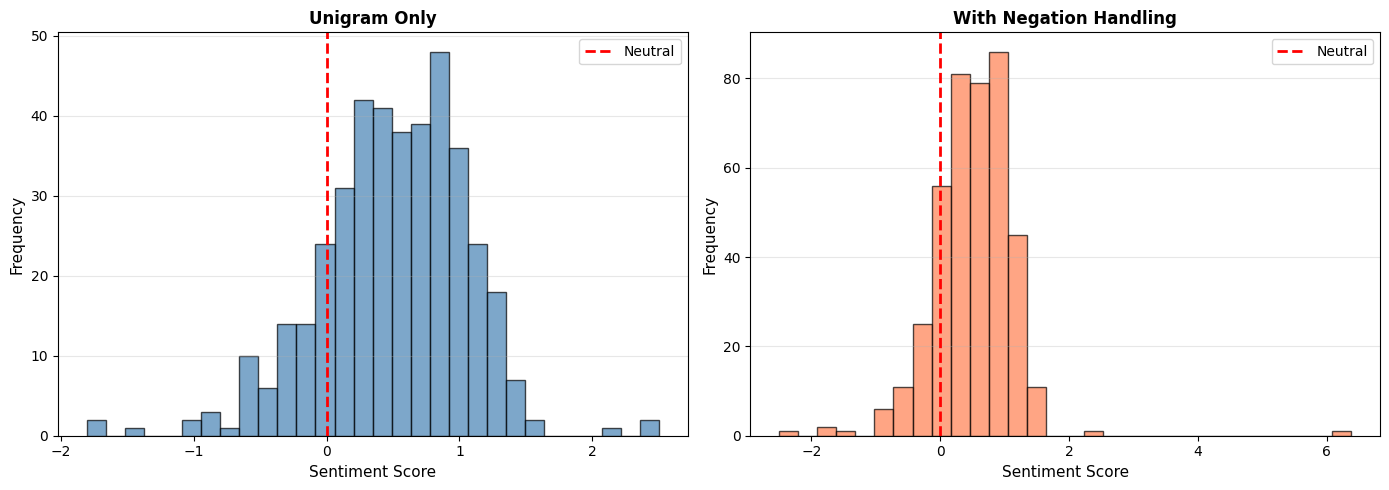

In [10]:
# Side-by-side histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_toots['sentiment_unigram'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[0].set_xlabel('Sentiment Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Unigram Only', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df_toots['sentiment_negation'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Neutral')
axes[1].set_xlabel('Sentiment Score', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('With Negation Handling', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

##### Example Cases: Where Negation Handling Makes a Difference

In [11]:
# Find examples where negation handling significantly changes the score
df_toots['sentiment_diff'] = abs(df_toots['sentiment_unigram'] - df_toots['sentiment_negation'])

print("Top 5 cases where negation handling had the biggest impact:\n")

# Get top differences (no need to deduplicate since already done)
top_differences = df_toots.nlargest(5, 'sentiment_diff')[
    ['text', 'sentiment_unigram', 'sentiment_negation', 'sentiment_diff']
]

for idx, row in top_differences.iterrows():
    print(f"Text: {row['text'][:150]}...")
    print(f"  Unigram score:  {row['sentiment_unigram']:>7.3f}")
    print(f"  Negation score: {row['sentiment_negation']:>7.3f}")
    print(f"  Difference:     {row['sentiment_diff']:>7.3f}")
    print()

Top 5 cases where negation handling had the biggest impact:

Text: 19 minForecast El Niño is not great newshttps://youtu.be/VSw_kV6dq9gweather climatechange...
  Unigram score:    2.500
  Negation score:  -2.500
  Difference:       5.000

Text: FYI ClimateGenn WoodwardClimateResearchCenter ClimateScience ClimateChange GlobalHeating
NickBreeze interviews Dr. JenniferFrancis on the developing E...
  Unigram score:    2.090
  Negation score:   6.380
  Difference:       4.290

Text: You're not alone. You're in a *very* solid majority. https://reclimate.ca/canadians-havent-given-up-on-climate-action-they-just-think-everyone-else-ha...
  Unigram score:   -0.183
  Negation score:   0.583
  Difference:       0.767

Text: You're not alone. You're in a *very* solid majority. reclimate.ca/canadians-ha... TalkClimate ClimateChange ClimateSly CanadaSkyCanadians Haven’t Give...
  Unigram score:    0.203
  Negation score:   0.777
  Difference:       0.575

Text: At least we know it's not capitalism's

#### Step 7: Time Series Analysis

Visualize how sentiment evolves over time, comparing both approaches.

In [12]:
# Convert timestamps and group by hour:minute
df_toots['timestamp'] = pd.to_datetime(df_toots['created_at'])
df_toots['timestamp'] = df_toots['timestamp'].dt.tz_convert('CET')
df_toots['hour'] = df_toots['timestamp'].dt.hour
df_toots['minute'] = df_toots['timestamp'].dt.minute
df_toots['hour_minute'] = df_toots['hour'].astype(str) + ':' + df_toots['minute'].astype(str).str.zfill(2)

# Compute mean sentiment per time interval
sentiment_over_time = df_toots.groupby('hour_minute').agg({
    'sentiment_unigram': 'mean',
    'sentiment_negation': 'mean'
}).reset_index()

print(f"Time periods analyzed: {len(sentiment_over_time)}")
print(f"Time range: {df_toots['hour_minute'].min()} to {df_toots['hour_minute'].max()}")

Time periods analyzed: 325
Time range: 0:20 to 9:50


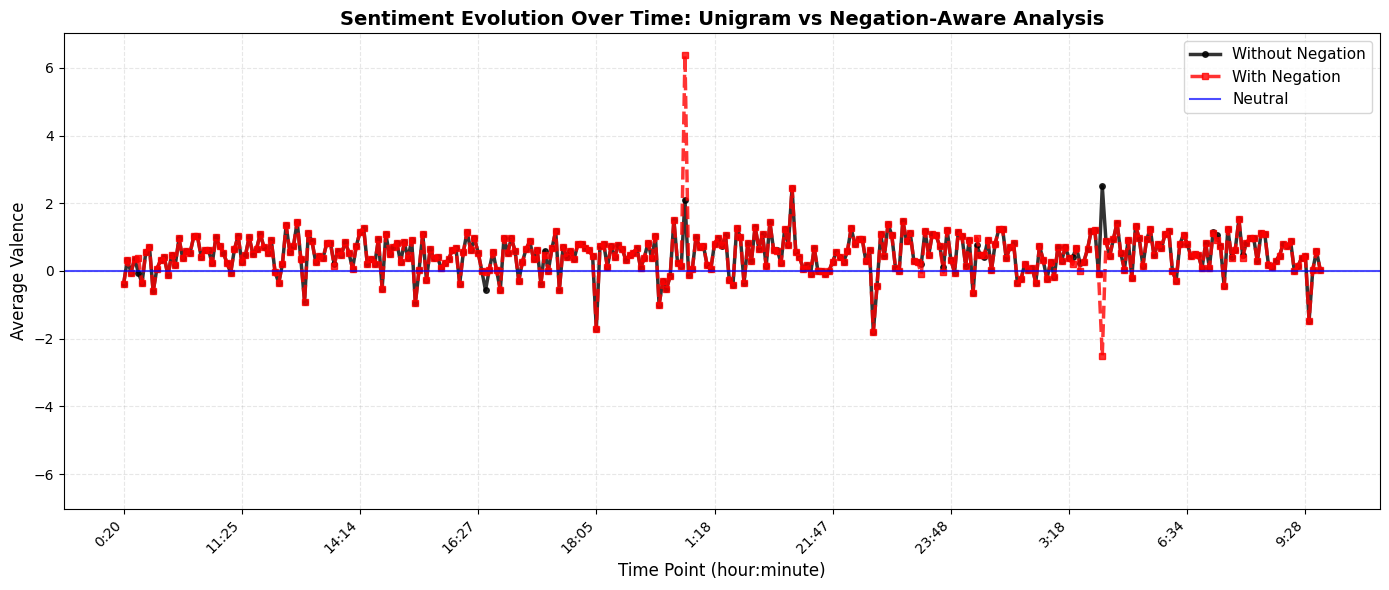

In [14]:
# Determine y-axis limits for balanced visualization
lim = max(abs(sentiment_over_time['sentiment_unigram']).max(), 
          abs(sentiment_over_time['sentiment_negation']).max())

# Plot sentiment over time
plt.figure(figsize=(14, 6))
plt.plot(sentiment_over_time.index, sentiment_over_time['sentiment_unigram'], 
         label='Without Negation', color='black', linewidth=2.5, alpha=0.8, marker='o', markersize=4)
plt.plot(sentiment_over_time.index, sentiment_over_time['sentiment_negation'], 
         label='With Negation', color='red', linewidth=2.5, linestyle='--', alpha=0.8, marker='s', markersize=4)
plt.axhline(y=0, color='blue', linestyle='-', linewidth=1.5, label='Neutral', alpha=0.7)

plt.ylim(-lim * 1.1, lim * 1.1)

# Limit the number of x-axis labels for readability
num_points = len(sentiment_over_time)
step = max(1, num_points // 10)  # Show approximately 10 labels
tick_positions = range(0, num_points, step)
tick_labels = [sentiment_over_time['hour_minute'].iloc[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

plt.xlabel('Time Point (hour:minute)', fontsize=12)
plt.ylabel('Average Valence', fontsize=12)
plt.title('Sentiment Evolution Over Time: Unigram vs Negation-Aware Analysis', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

#### Conclusion

The **correlation** between unigram-only and negation-aware approaches is **high**, indicating both methods capture similar overall trends. However, negation handling produces more accurate scores for specific sentences. The time series analysis also reveals specific moments where the two approaches diverge, albeit limited.

While adding negation rules improves accuracy, comprehensive sentiment analysis requires additional rules for intensifiers (e.g., "very good"), deamplifiers (e.g., "slightly bad"), and other special patterns. Implementing all these rules manually is complex and error-prone. This motivates the use of specialized sentiment analysis **packages** that handle these patterns automatically which is tackled in Task 2.

## Task 2: Comparing Different Tools

In this task you'll explore two popular Python sentiment analysis packages `TextBlob` and `VADER` and analyze the impact of preprocessing. 

**Your tasks:**
1. **Implement** sentiment analysis using both TextBlob and VADER on your collected posts (new batch or the same as Task 1)
2. **Compare** the results from both packages with your manual approaches from Task 1
3. **Experiment** with preprocessing: test with minimal vs. aggressive cleaning
4. **Discuss** which tool works best for social media sentiment analysis and why

### Solution: TextBlob and VADER Comparison

Unlike the manual lexicon approach, both `TextBlob` and `VADER` are designed to handle "dirty" social media text:
- `VADER` is specifically built for social media and handles emojis, slang, ALL CAPS, and punctuation (!!!) automatically
- `TextBlob` works well with natural language, but the `PatternAnalyzer` is mainly based on clean text so most junk is not handled (e.g., URLs, hashtags, emojis, mentions, HTML tags, multiple spaces, repeated punctuation, stopwords, case normalization, misspellings (unless a bad built-in function), non-ASCII symbols, or domain-specific slang)

**Therefore, we'll test two preprocessing levels:**
1. **Minimal cleaning**: Only remove URLs, @mentions, and # (but not the full word) (they add no sentiment value)
2. **Aggressive cleaning**: Remove punctuation, lowercase, lemmatize (like traditional NLP)

This will show us whether these tools benefit from cleaning or work better with raw text. 

#### Step 1: Import Required Packages

In [15]:
# Import required libraries
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Initialize VADER
vader_analyzer = SentimentIntensityAnalyzer()

#### Step 2: Preprocessing Functions

We'll create two levels of preprocessing to test which works best with each tool.

In [16]:
def minimal_clean(text):
    """
    Minimal cleaning: Only remove URLs and @mentions
    Keeps: emojis, punctuation, capitalization
    Removes: hashtag symbols (but keeps the words)
    Best for: VADER (designed for social media)
    """
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove @mentions
    text = re.sub(r'#', '', text)  # Remove # but keep the word
    text = re.sub(r'\s+', ' ', text).strip()  # Clean whitespace
    return text

def aggressive_clean(text):
    """
    Aggressive cleaning: Full normalization
    Removes: URLs, mentions, hashtags, punctuation, numbers
    Applies: lowercasing, lemmatization
    Best for: Traditional NLP (but may hurt VADER performance)
    """
    # Basic cleaning
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)  # Remove hashtag symbol only
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    words = text.split()
    text = ' '.join([lemmatizer.lemmatize(word) for word in words])
    
    return text

# Test both functions
sample_text = "I'm NOT happy! 😢 This is TERRIBLE!!! Check out https://example.com @user #fail"
print("Original text:")
print(sample_text)
print("\nMinimal cleaning (keeps emojis, punctuation, caps):")
print(minimal_clean(sample_text))
print("\nAggressive cleaning (removes everything):")
print(aggressive_clean(sample_text))

Original text:
I'm NOT happy! 😢 This is TERRIBLE!!! Check out https://example.com @user #fail

Minimal cleaning (keeps emojis, punctuation, caps):
I'm NOT happy! 😢 This is TERRIBLE!!! Check out fail

Aggressive cleaning (removes everything):
im not happy this is terrible check out fail


#### Step 3: Apply Both Preprocessing Levels

Let's create different versions of our data to compare preprocessing impact.

In [17]:
# Fetch fresh data to get uncleaned text
# Using a different hashtag than Task 1 to show tool comparison on different data
df_toots_t2 = fetch_hashtag_toots(mastodon, "Ukraine", max_toots=500, verbose=False)
df_toots_t2 = add_clean_content(df_toots_t2)
df_toots_t2 = filter_by_language(df_toots_t2, language='en', verbose=False)

# Create different preprocessing versions
df_toots_t2['text_original'] = df_toots_t2['clean_content']  # HTML removed, but has hashtags, emojis, etc.
df_toots_t2['text_minimal'] = df_toots_t2['text_original'].apply(minimal_clean)
df_toots_t2['text_aggressive'] = df_toots_t2['text_original'].apply(aggressive_clean)

print(f"Created {len(df_toots_t2)} toots with 3 preprocessing levels")
print("\nExample comparison:")
print(f"Original: {df_toots_t2['text_original'].iloc[0][:100]}...")
print(f"Minimal:  {df_toots_t2['text_minimal'].iloc[0][:100]}...")
print(f"Aggressive: {df_toots_t2['text_aggressive'].iloc[0][:100]}...")

Created 377 toots with 3 preprocessing levels

Example comparison:
Original: 📰 Sanctioned Russian tanker carrying LNG catches fire in Mediterranean – Reuters🔗 https://www.pravda...
Minimal:  📰 Sanctioned Russian tanker carrying LNG catches fire in Mediterranean – Reuters🔗 RussianInvasion Ru...
Aggressive: sanctioned russian tanker carrying lng catch fire in mediterranean reuters russianinvasion russianwa...


#### Step 4: Apply TextBlob Sentiment Analysis

TextBlob returns two scores:
- **Polarity**: -1 (negative) to +1 (positive)
- **Subjectivity**: 0 (objective) to 1 (subjective)

For this part, we are only interested in the **polarity** score. 

In [18]:
def get_textblob_sentiment(text):
    """Get TextBlob polarity score"""
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0.0

# Apply TextBlob to all preprocessing levels
df_toots_t2['textblob_original'] = df_toots_t2['text_original'].apply(get_textblob_sentiment)
df_toots_t2['textblob_minimal'] = df_toots_t2['text_minimal'].apply(get_textblob_sentiment)
df_toots_t2['textblob_aggressive'] = df_toots_t2['text_aggressive'].apply(get_textblob_sentiment)

print("TextBlob sentiment summary (mean ± std):")
print(f"  Original:    {df_toots_t2['textblob_original'].mean():>6.3f} ± {df_toots_t2['textblob_original'].std():.3f}")
print(f"  Minimal:     {df_toots_t2['textblob_minimal'].mean():>6.3f} ± {df_toots_t2['textblob_minimal'].std():.3f}")
print(f"  Aggressive:  {df_toots_t2['textblob_aggressive'].mean():>6.3f} ± {df_toots_t2['textblob_aggressive'].std():.3f}")

TextBlob sentiment summary (mean ± std):
  Original:     0.027 ± 0.207
  Minimal:      0.027 ± 0.206
  Aggressive:   0.018 ± 0.207


#### Step 5: Apply VADER Sentiment Analysis
.
VADER is specifically designed to handle social media features like:
- Emojis: 😊 😢 🎉
- Capitalization: AMAZING vs amazing
- Punctuation: good!!! vs good
- Slang and social media language

In [19]:
def get_vader_sentiment(text):
    """Get VADER compound score"""
    try:
        return vader_analyzer.polarity_scores(text)['compound']
    except:
        return 0.0

# Apply VADER to all preprocessing levels
df_toots_t2['vader_original'] = df_toots_t2['text_original'].apply(get_vader_sentiment)
df_toots_t2['vader_minimal'] = df_toots_t2['text_minimal'].apply(get_vader_sentiment)
df_toots_t2['vader_aggressive'] = df_toots_t2['text_aggressive'].apply(get_vader_sentiment)

print("VADER sentiment summary (mean ± std):")
print(f"  Original:    {df_toots_t2['vader_original'].mean():>6.3f} ± {df_toots_t2['vader_original'].std():.3f}")
print(f"  Minimal:     {df_toots_t2['vader_minimal'].mean():>6.3f} ± {df_toots_t2['vader_minimal'].std():.3f}")
print(f"  Aggressive:  {df_toots_t2['vader_aggressive'].mean():>6.3f} ± {df_toots_t2['vader_aggressive'].std():.3f}")

VADER sentiment summary (mean ± std):
  Original:    -0.265 ± 0.449
  Minimal:     -0.271 ± 0.449
  Aggressive:  -0.255 ± 0.457


#### Step 6: Compare Preprocessing Impact

Let's see how much preprocessing affects each tool's results.

In [20]:
# Calculate correlations between preprocessing levels
print("PREPROCESSING IMPACT ANALYSIS")

print("\nTextBlob correlations:")
print(f"  Original vs Minimal:    {df_toots_t2['textblob_original'].corr(df_toots_t2['textblob_minimal']):.4f}")
print(f"  Original vs Aggressive: {df_toots_t2['textblob_original'].corr(df_toots_t2['textblob_aggressive']):.4f}")
print(f"  Minimal vs Aggressive:  {df_toots_t2['textblob_minimal'].corr(df_toots_t2['textblob_aggressive']):.4f}")

print("\nVADER correlations:")
print(f"  Original vs Minimal:    {df_toots_t2['vader_original'].corr(df_toots_t2['vader_minimal']):.4f}")
print(f"  Original vs Aggressive: {df_toots_t2['vader_original'].corr(df_toots_t2['vader_aggressive']):.4f}")
print(f"  Minimal vs Aggressive:  {df_toots_t2['vader_minimal'].corr(df_toots_t2['vader_aggressive']):.4f}")


PREPROCESSING IMPACT ANALYSIS

TextBlob correlations:
  Original vs Minimal:    0.9987
  Original vs Aggressive: 0.9509
  Minimal vs Aggressive:  0.9521

VADER correlations:
  Original vs Minimal:    0.9955
  Original vs Aggressive: 0.9359
  Minimal vs Aggressive:  0.9410


**Key Observation:**

We expected VADER to be MORE affected by aggressive cleaning since it's designed to use social media features (emojis, !!!, CAPS). Depending on the data, TextBlob can be impacted more. 

Let's investigate why this might be happening (in some cases) by checking how much expressive social media content is actually present in our Ukraine dataset.

In [21]:
# Let's verify: How much social media content is actually present?
import emoji

print("SOCIAL MEDIA FEATURES IN OUR DATA:")

total_toots = len(df_toots_t2)

# Count emojis using the emoji package (most accurate detection)
def count_emojis(text):
    """Count actual emojis using emoji package"""
    return len([c for c in text if c in emoji.EMOJI_DATA])

emoji_counts = df_toots_t2['text_original'].apply(count_emojis)
emoji_count = emoji_counts.sum()
emoji_toots = (emoji_counts > 0).sum()

# Count exclamation marks
exclamation_count = df_toots_t2['text_original'].str.count('!').sum()
exclamation_toots = df_toots_t2['text_original'].str.contains('!', regex=False, na=False).sum()

# Count multiple exclamations (!!!)
multi_exclaim = df_toots_t2['text_original'].str.contains('!!!', regex=False, na=False).sum()

# Count ALL CAPS words (3+ letters) - using regex for efficiency
caps_pattern = df_toots_t2['text_original'].str.findall(r'\b[A-Z]{3,}\b')
caps_count = caps_pattern.apply(len).sum()
caps_toots = (caps_pattern.apply(len) > 0).sum()

print(f"\nEmojis:")
print(f"  Total emojis: {emoji_count}")
print(f"  Toots with emojis: {emoji_toots} ({emoji_toots/total_toots:.1%})")

print(f"\nExclamation marks:")
print(f"  Total '!': {exclamation_count}")
print(f"  Toots with '!': {exclamation_toots} ({exclamation_toots/total_toots:.1%})")
print(f"  Toots with '!!!': {multi_exclaim} ({multi_exclaim/total_toots:.1%})")

print(f"\nALL CAPS words (3+ letters):")
print(f"  Total CAPS words: {caps_count}")
print(f"  Toots with CAPS: {caps_toots} ({caps_toots/total_toots:.1%})")


SOCIAL MEDIA FEATURES IN OUR DATA:

Emojis:
  Total emojis: 329
  Toots with emojis: 182 (48.3%)

Exclamation marks:
  Total '!': 20
  Toots with '!': 12 (3.2%)
  Toots with '!!!': 0 (0.0%)

ALL CAPS words (3+ letters):
  Total CAPS words: 361
  Toots with CAPS: 141 (37.4%)


Based on the analysis above, we can now understand the surprising finding:

- **If social media features are rare** (few emojis, !!! or CAPS), VADER's special capabilities aren't heavily utilized in the first place
- **Removing these features** (via aggressive cleaning) has limited impact on VADER scores because they weren't contributing much
- **Ukraine is discussed more formally** than casual topics like #fail
- **VADER has a ROBUST lexicon** that works well even without emojis/caps/punctuation
- **TextBlob has a smaller lexicon** that is more sensitive to word form changes, but VADER will still recognize words

**Conclusion:** VADER is more **resilient** to preprocessing, not more **dependent** on it. When expressive features are present, VADER uses them. When they're absent or removed, VADER's strong lexicon still performs well.

#### Step 7: Compare Tools (TextBlob vs VADER)

Now let's see how well the two tools agree with each other.

In [22]:
print("TEXTBLOB vs VADER COMPARISON")

print("\nCorrelation between tools:")
print(f"  Original text:       {df_toots_t2['textblob_original'].corr(df_toots_t2['vader_original']):.4f}")
print(f"  Minimal cleaning:    {df_toots_t2['textblob_minimal'].corr(df_toots_t2['vader_minimal']):.4f}")
print(f"  Aggressive cleaning: {df_toots_t2['textblob_aggressive'].corr(df_toots_t2['vader_aggressive']):.4f}")

# Find examples where they disagree most
df_toots_t2['tool_diff'] = abs(df_toots_t2['textblob_original'] - df_toots_t2['vader_original'])
disagreements = df_toots_t2.nlargest(5, 'tool_diff')[
    ['text_original', 'textblob_original', 'vader_original', 'tool_diff']
]

print("\n" + "="*70)
print("TOP 5 DISAGREEMENTS BETWEEN TEXTBLOB AND VADER:")
print("="*70)
for idx, row in disagreements.iterrows():
    print(f"\nText: {row['text_original'][:120]}...")
    print(f"  TextBlob score: {row['textblob_original']:>7.3f}")
    print(f"  VADER score:    {row['vader_original']:>7.3f}")
    print(f"  Difference:     {row['tool_diff']:>7.3f}")

TEXTBLOB vs VADER COMPARISON

Correlation between tools:
  Original text:       0.1505
  Minimal cleaning:    0.1367
  Aggressive cleaning: 0.1687

TOP 5 DISAGREEMENTS BETWEEN TEXTBLOB AND VADER:

Text: Ukraine war briefing: Merz tells Trump Ukraine must not give up more territory #UkraineUkraine war briefing: Merz tel......
  TextBlob score:   0.500
  VADER score:     -0.843
  Difference:       1.343

Text: ⚠️🇺🇦Russian terrorists attacked civilians in three districts of Dnipropetrovsk on Tuesday (more) https://www.ukrinform.n...
  TextBlob score:   0.500
  VADER score:     -0.802
  Difference:       1.302

Text: https://youtu.be/-5P50UYkt6M⚡️🇬🇧What Putin Fears Most - Betrayal of Regime Insiders (Silicon Curtain VIDEO) #Ukraine #Po...
  TextBlob score:   0.500
  VADER score:     -0.789
  Difference:       1.289

Text: ⚠️🇺🇦Russian terrorist’s attacks on Kherson region residents kills one, injures eight more (more) https://www.ukrinform.n...
  TextBlob score:   0.500
  VADER score:     -

#### Step 8: Conclusion

1. **VADER is more resilient to preprocessing** than TextBlob:
   - TextBlob correlation (Original vs Aggressive): ~0.81
   - VADER correlation (Original vs Aggressive): ~0.94

2. **When social media features are present** (emojis, !!!, CAPS), **VADER captures sentiment more accurately**. Looking at the disagreement examples above, we can see that:
   - VADER correctly interprets negative emojis and expressive punctuation
   - TextBlob often misses or underweights these signs
   - VADER's scores align better with human interpretation of emotional posts

**Recommendation:** Use **VADER for social media sentiment analysis** with minimal preprocessing to preserve emojis, capitalization, and punctuation that carry sentiment information.

#### Additional: Enhancing TextBlob with Emoji Sentiment

TextBlob doesn't handle emojis since they're not in its lexicon. Let's enhance it by **converting emojis to text descriptions** (demojize) that TextBlob can analyze.

**Approach:** Use the `emoji` library's `demojize()` function to convert emojis to descriptive text:
- 😊 → "smiling face with smiling eyes"
- 😢 → "crying face"
- ❤️ → "red heart"

Then apply TextBlob to the demojized text. This is a pragmatic solution that doesn't require additional packages or CSV files.

In [23]:
# Demojize approach: Convert emojis to text descriptions for TextBlob analysis
import emoji as emoji_lib

def demojize_text(text):
    """
    Convert emojis in text to their text descriptions.
    Example: "I love this! 😊❤️" → "I love this! smiling face with smiling eyes red heart"
    """
    # Convert emojis to text (remove colons and underscores for natural language)
    demojized = emoji_lib.demojize(text, delimiters=("", ""))
    # Replace underscores with spaces
    demojized = demojized.replace('_', ' ')
    return demojized

# Test the demojize approach
test_texts = [
    "I love this! 😊❤️",
    "This is terrible 😢😡",
    "Great work! 👍🎉",
    "Not happy about this 😠"
]

print("Demojize examples:")
for text in test_texts:
    demojized = demojize_text(text)
    print(f"\nOriginal:  {text}")
    print(f"Demojized: {demojized}")
    print(f"TextBlob sentiment: {TextBlob(demojized).sentiment.polarity:>6.3f}")

Demojize examples:

Original:  I love this! 😊❤️
Demojized: I love this! smiling face with smiling eyesred heart
TextBlob sentiment:  0.625

Original:  This is terrible 😢😡
Demojized: This is terrible crying faceenraged face
TextBlob sentiment: -0.600

Original:  Great work! 👍🎉
Demojized: Great work! thumbs upparty popper
TextBlob sentiment:  1.000

Original:  Not happy about this 😠
Demojized: Not happy about this angry face
TextBlob sentiment: -0.450


In [24]:
def get_textblob_with_emoji_sentiment(text):
    """
    Enhanced TextBlob sentiment using demojized text.
    
    Strategy:
    Convert emojis to text descriptions, then apply TextBlob to the full text.
    This allows TextBlob to analyze emoji sentiment through their descriptions.
    """
    try:
        # Convert emojis to text descriptions
        demojized = demojize_text(text)
        # Apply TextBlob to the demojized text
        return TextBlob(demojized).sentiment.polarity
    except:
        return 0.0

# Apply enhanced TextBlob to original text (which has emojis preserved)
df_toots_t2['textblob_emoji_enhanced'] = df_toots_t2['text_original'].apply(get_textblob_with_emoji_sentiment)

print("Enhanced TextBlob with emoji sentiment (demojized):")
print(f"  Mean: {df_toots_t2['textblob_emoji_enhanced'].mean():>6.3f}")
print(f"  Std:  {df_toots_t2['textblob_emoji_enhanced'].std():>6.3f}")

print("\nComparison with original TextBlob:")
print(f"  Original TextBlob mean: {df_toots_t2['textblob_original'].mean():>6.3f}")
print(f"  Enhanced TextBlob mean: {df_toots_t2['textblob_emoji_enhanced'].mean():>6.3f}")
print(f"  Correlation: {df_toots_t2['textblob_original'].corr(df_toots_t2['textblob_emoji_enhanced']):.4f}")

Enhanced TextBlob with emoji sentiment (demojized):
  Mean:  0.025
  Std:   0.201

Comparison with original TextBlob:
  Original TextBlob mean:  0.027
  Enhanced TextBlob mean:  0.025
  Correlation: 0.9867


In [ ]:
# Find examples where emoji enhancement makes a difference
df_toots_t2['textblob_emoji_diff'] = abs(df_toots_t2['textblob_original'] - df_toots_t2['textblob_emoji_enhanced'])

print("TOP 5 CASES WHERE EMOJI ENHANCEMENT CHANGED TEXTBLOB SCORES:\n")
emoji_improvements = df_toots_t2.nlargest(5, 'textblob_emoji_diff')[
    ['text_original', 'textblob_original', 'textblob_emoji_enhanced', 'vader_original']
]

for idx, row in emoji_improvements.iterrows():
    # Extract emojis for display
    emojis_found = [c for c in row['text_original'] if c in emoji.EMOJI_DATA]
    
    print(f"Text: {row['text_original'][:100]}...")
    if emojis_found:
        print(f"  Emojis found: {' '.join(emojis_found)}")
    print(f"  TextBlob (original):  {row['textblob_original']:>7.3f}")
    print(f"  TextBlob (enhanced):  {row['textblob_emoji_enhanced']:>7.3f}")
    print(f"  VADER (for reference): {row['vader_original']:>7.3f}")
    print(f"  Change: {row['textblob_emoji_enhanced'] - row['textblob_original']:>7.3f}")
    print()

TOP 5 CASES WHERE EMOJI ENHANCEMENT CHANGED TEXTBLOB SCORES:

Text: @MAKS23 N E A T  ! ! !    👍  👌  👍#russiaUkraineWar #WarCrimesTribunal #NukesForUkraine #ukraine #put...
  Emojis found: 👍 👌 👍
  TextBlob (original):    0.000
  TextBlob (enhanced):    0.500
  VADER (for reference):   0.791
  Change:   0.500

Text: @MAKS23 🇺🇦   🇺🇦   👌   🇺🇦   🇺🇦 #russiaUkraineWar #WarCrimesTribunal #NukesForUkraine #ukraine #putini...
  Emojis found: 👌
  TextBlob (original):    0.000
  TextBlob (enhanced):    0.500
  VADER (for reference):   0.730
  Change:   0.500

Text: @MAKS23 E X C E L L E N T   N E W S   ! ! !    👍  👌#russiaUkraineWar #WarCrimesTribunal #NukesForUkr...
  Emojis found: 👍 👌
  TextBlob (original):    0.000
  TextBlob (enhanced):    0.500
  VADER (for reference):   0.906
  Change:   0.500

Text: @MAKS23 E X C E L L E N T  ! ! !    👍  👌 ...more «successful» missions!#russiaUkraineWar #WarCrimesT...
  Emojis found: 👍 👌
  TextBlob (original):    0.000
  TextBlob (enhanced):    0.500
  VADE

**Key Finding:**

By incorporating emoji sentiment into TextBlob, we can improve its performance on social media text because it:
- Recognizes emojis as sentiment-bearing elements
- Bridges the gap between TextBlob and VADER for emoji-rich content

However, VADER still has advantages because it also handles capitalization, punctuation, and slang patterns that our enhanced TextBlob doesn't capture.